In [1]:
## OneHotEncoder
import pandas as pd
from sklearn.preprocessing import OneHotEncoder


In [2]:
data = pd.DataFrame({"Color":["Red","Green","Blue","Green","Red"]})
data

,Color
0,Red
1,Green
2,Blue
3,Green
4,Red


In [4]:
ohe = OneHotEncoder()
on_hot_cod = ohe.fit_transform(data[["Color"]])
print(on_hot_cod)

  (0, 2)	1.0
  (1, 1)	1.0
  (2, 0)	1.0
  (3, 1)	1.0
  (4, 2)	1.0


In [5]:
ohe = OneHotEncoder(sparse_output=False)
on_hot_cod = ohe.fit_transform(data[["Color"]])
print(on_hot_cod)

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [7]:
colName = ohe.get_feature_names_out(["Color"])
print(colName)
one_hot_df = pd.DataFrame(on_hot_cod,columns=colName)
one_hot_df

['Color_Blue' 'Color_Green' 'Color_Red']


,Color_Blue,Color_Green,Color_Red
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0


In [8]:
import pandas as pd
data = pd.DataFrame({
    "Color":["Red","Green","Blue","Green","Red"]
})
one_hot_df = pd.get_dummies(data)
one_hot_df

,Color_Blue,Color_Green,Color_Red
0,False,False,True
1,False,True,False
2,True,False,False
3,False,True,False
4,False,False,True


In [ ]:
import pandas as pd
data = pd.DataFrame({
    "Color":["Red","Green","Blue","Green","Red"]
})
one_hot_df = pd.get_dummies(data,drop_first=True)#共線性
one_hot_df

,Color_Green,Color_Red
0,False,True
1,True,False
2,False,False
3,True,False
4,False,True


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("./Ames_NO_Missing_Data.csv")
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,3,2010,WD,Normal,189900


In [ ]:
df.info()

當我們將類別數據以數字形式編碼時需要小心。我們需要確保數字之間的關係對模型來說是有意義的。例如，MSSubClass 的編碼本質上只是每個類別的數字代碼：

**MSSubClass: 住宅類型。**

- **20**	1-STOREY 1946 & NEWER ALL STYLES 一層樓 1946年及以後所有風格
- **30**	1-STOREY 1945 & OLDER 一層樓 1945年及更早
- **40**	1-STOREY W/FINISHED ATTIC ALL AGES 一層樓帶完成的閣樓 所有年齡
- **45**	1-1/2 STORY - UNFINISHED ALL AGES 一層半未完成 所有年齡
- **50**	1-1/2 STORY FINISHED ALL AGES 一層半完成 所有年齡
- **60**	2-STORY 1946 & NEWER 二層樓 1946年及以後
- **70**	2-STORY 1945 & OLDER 二層樓 1945年及更早
- **75**	2-1/2 STORY ALL AGES 二層半 所有年齡
- **80**	SPLIT OR MULTI-LEVEL 分割或多層
- **85**	SPLIT FOYER 分割門廳
- **90**	DUPLEX - ALL STYLES AND AGES 雙拼 - 所有風格和年齡
- **120**	1-STORY PUD (Planned Unit Development) - 1946 & NEWER 一層樓PUD（計劃單元開發）- 1946年及以後
- **150**	1-1/2 STORY PUD - ALL AGES 一層半PUD - 所有年齡
- **160**	2-STORY PUD - 1946 & NEWER 二層樓PUD - 1946年及以後
- **180**	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER PUD - 多層 - 包括分割層/門廳
- **190**	2 FAMILY CONVERSION - ALL STYLES AND AGES 兩家庭改造 - 所有風格和年齡

數字本身似乎並無與其他數字相關。雖然 30 > 20 是對的，但“1-STOREY 1945 & OLDER” > “1-STOREY 1946 & NEWER ALL STYLES”實際上並無意義。需要注意的是，這並不總是這樣，例如將頭等艙和二等艙編碼為 1 和 2 的情況。確保你完全理解你的數據集，以檢查需要轉換/更改的內容。

In [13]:
df["MS SubClass"] = df["MS SubClass"].astype(str)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 76 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2925 non-null   object 
 1   MS Zoning        2925 non-null   object 
 2   Lot Frontage     2925 non-null   float64
 3   Lot Area         2925 non-null   int64  
 4   Street           2925 non-null   object 
 5   Lot Shape        2925 non-null   object 
 6   Land Contour     2925 non-null   object 
 7   Utilities        2925 non-null   object 
 8   Lot Config       2925 non-null   object 
 9   Land Slope       2925 non-null   object 
 10  Neighborhood     2925 non-null   object 
 11  Condition 1      2925 non-null   object 
 12  Condition 2      2925 non-null   object 
 13  Bldg Type        2925 non-null   object 
 14  House Style      2925 non-null   object 
 15  Overall Qual     2925 non-null   int64  
 16  Overall Cond     2925 non-null   int64  
 17  Year Built    

In [16]:
df_nums = df.select_dtypes(exclude=["object"])#排除object
df_objs = df.select_dtypes(include=["object"])#保留


In [19]:
df_nums.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Lot Frontage     2925 non-null   float64
 1   Lot Area         2925 non-null   int64  
 2   Overall Qual     2925 non-null   int64  
 3   Overall Cond     2925 non-null   int64  
 4   Year Built       2925 non-null   int64  
 5   Year Remod/Add   2925 non-null   int64  
 6   Mas Vnr Area     2925 non-null   float64
 7   BsmtFin SF 1     2925 non-null   float64
 8   BsmtFin SF 2     2925 non-null   float64
 9   Bsmt Unf SF      2925 non-null   float64
 10  Total Bsmt SF    2925 non-null   float64
 11  1st Flr SF       2925 non-null   int64  
 12  2nd Flr SF       2925 non-null   int64  
 13  Low Qual Fin SF  2925 non-null   int64  
 14  Gr Liv Area      2925 non-null   int64  
 15  Bsmt Full Bath   2925 non-null   float64
 16  Bsmt Half Bath   2925 non-null   float64
 17  Full Bath     

In [ ]:
df_objs.info()

In [22]:
df_objs = pd.get_dummies(df_objs,drop_first=True)
df_objs

,MS SubClass_150,MS SubClass_160,MS SubClass_180,MS SubClass_190,MS SubClass_20,MS SubClass_30,MS SubClass_40,MS SubClass_45,MS SubClass_50,MS SubClass_60,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2921,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2922,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2923,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


# MinMaxScaler
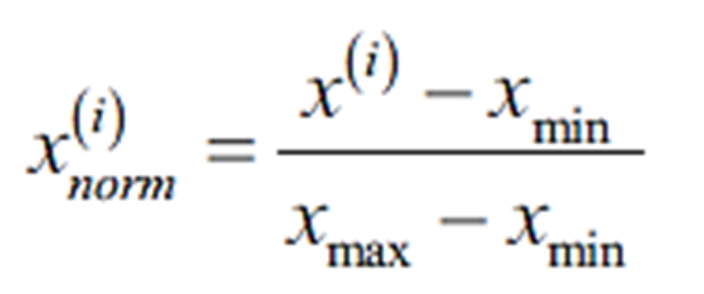


In [24]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

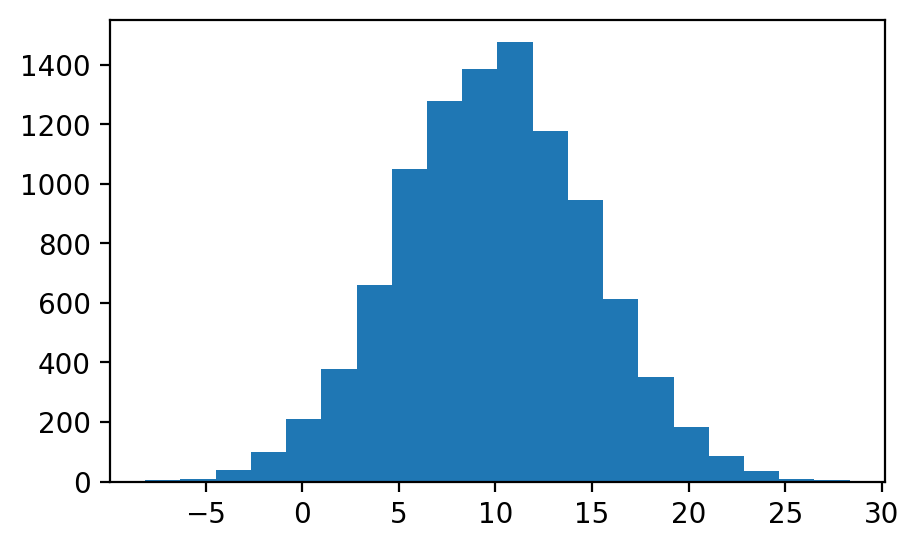

In [29]:
data = np.random.normal(10,5,10000)
plt.figure(figsize=(5,3),dpi=200)
plt.hist(data,20)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
minMaxScaler =  scaler.fit(data.reshape(-1,1))
data_new = minMaxScaler.transform(data.reshape(-1,1))
data_new

array([[0.61999991],
       [0.51644475],
       [0.388101  ],
       ...,
       [0.73396659],
       [0.49962209],
       [0.63283139]])

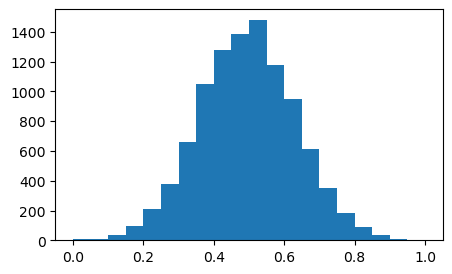

In [32]:
plt.figure(figsize=(5,3))
plt.hist(data_new,20)
plt.show()

## 均勻分配轉換

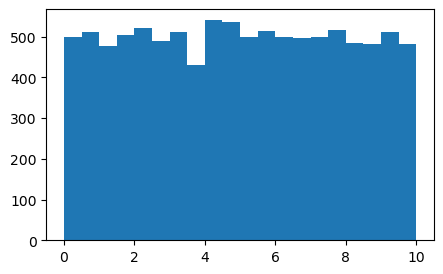

In [37]:
data = np.random.uniform(0,10,10000)
plt.figure(figsize=(5,3))
plt.hist(data,20)
plt.show()

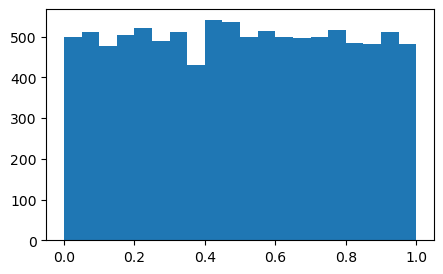

In [38]:
scaler = MinMaxScaler()
data_new = scaler.fit_transform(data.reshape(-1,1))
plt.figure(figsize=(5,3))
plt.hist(data_new,20)
plt.show()

In [ ]:
data = [[-1,2],
        [-0.5,6],
        [0,10],
        [1,18]]
scaler = MinMaxScaler()
scaler.fit(data)
print(scaler.data_min_)
print(scaler.data_max_)


[-1.  2.]
[ 1. 18.]


In [41]:
data_new = scaler.transform(data)
print(data_new)

[[0.   0.  ]
 [0.25 0.25]
 [0.5  0.5 ]
 [1.   1.  ]]


In [42]:
data2 = [[-0.5,6]]
data_new2 = scaler.transform(data2)
print(data_new2)

[[0.25 0.25]]


In [43]:
scaler.inverse_transform(data_new2)#資料還原

array([[-0.5,  6. ]])

In [44]:
data2 = [[-2,20]]
data_new2 = scaler.transform(data2)
print(data_new2)


[[-0.5    1.125]]


In [45]:
scaler = MinMaxScaler(feature_range=(-1,1))#最小-1最大1
data_new = scaler.fit_transform(data)
print(data_new)


[[-1.  -1. ]
 [-0.5 -0.5]
 [ 0.   0. ]
 [ 1.   1. ]]


In [52]:
scaler = MinMaxScaler(feature_range=(-1,1),clip=True)
scaler.fit(data)
scaler.transform(data2)



array([[-1.,  1.]])

In [53]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [54]:
X,y = datasets.load_iris(return_X_y=True)
X,y

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
        [5

In [71]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [72]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


In [73]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_std,y_train)


LogisticRegression()

In [74]:
y_pred = clf.predict(X_test_std)
print(f"{accuracy_score(y_test,y_pred):.2f}")

0.97


In [75]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[ 9  0  0]
 [ 0  6  1]
 [ 0  0 14]]


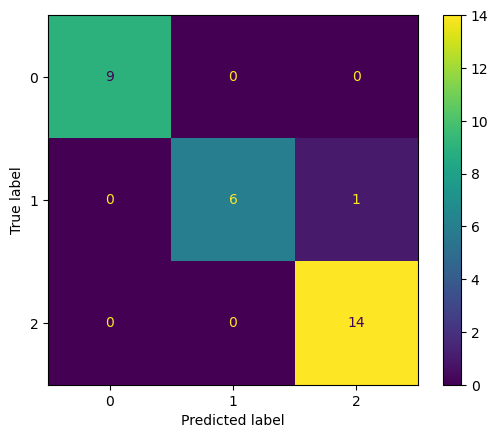

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay
dips = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred))
dips.plot()
plt.show()

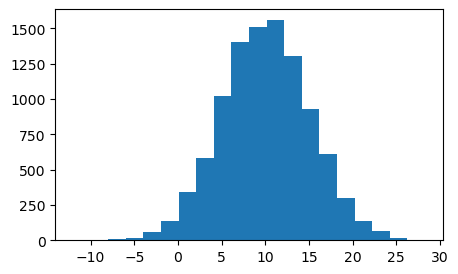

In [77]:
data = np.random.normal(10,5,10000)
plt.figure(figsize=(5,3))
plt.hist(data,20)
plt.show()

## StandardScaler
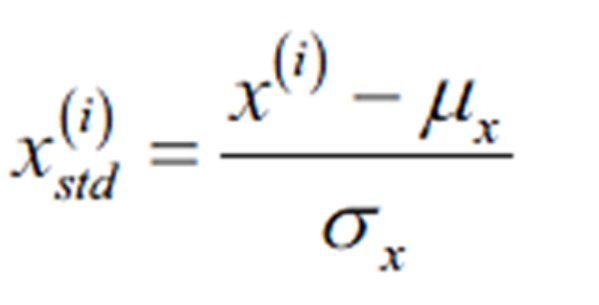

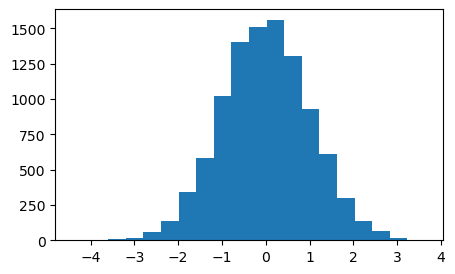

In [78]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
data_new = scaler.fit_transform(data.reshape(-1,1))
plt.figure(figsize=(5,3))
plt.hist(data_new,20)
plt.show()

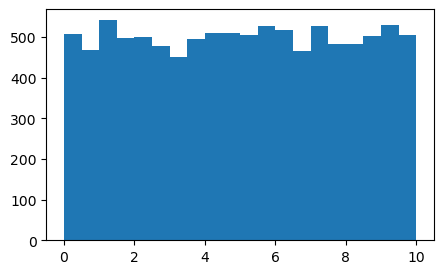

In [80]:
data = np.random.uniform(0,10,10000)
plt.figure(figsize=(5,3))
plt.hist(data,20)
plt.show()

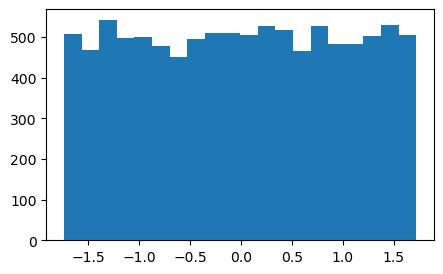

In [81]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
data_new = scaler.fit_transform(data.reshape(-1,1))
plt.figure(figsize=(5,3))
plt.hist(data_new,20)
plt.show()